# Bitcoin Statistical Inference

## Role
HAC Diebold–Mariano inference with Holm family-wise correction.

## Inputs
Ten frozen/reconstructed forecast vectors.

## Outputs
`bitcoin_dm_pairwise_results_hac_holm.csv`.

## Depends On
07–10.

## Authoritative Status
AUTHORITATIVE CORRECTED INFERENCE

## What This Notebook Does Not Do
It does not rerun models or silently replace the historical DM artifact.


In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
from src.bitcoin_pipeline import *
RUN_GENERATION = False
PROMOTE_TO_AUTHORITATIVE = False


In [2]:
# Load the frozen HAC Diebold–Mariano pairwise results.
dm = pd.read_csv(ROOT / 'results' / 'bitcoin_dm_pairwise_results_hac_holm.csv')

# Validate the complete 45-pair, ten-model family.
assert dm.shape[0] == 45
assert len(set(dm['Model A']) | set(dm['Model B'])) == 10

# Display the unchanged inference table.
dm

,Model A,Model B,N,HAC Lag,Mean loss differential,DM statistic,Raw p-value,Lower-RMSE model,Absolute RMSE difference,Relative RMSE difference,Practical interpretation,Holm-adjusted p-value,Significant raw?,Significant Holm?
0,Naive,Simple Exponential Smoothing — Rolling One-Step,1061,6,-7.814318e+03,-0.396730,6.915669e-01,Naive,2.106651,0.001137,Small,1.000000e+00,False,False
1,Naive,Additive-Trend Exponential Smoothing,1061,6,-6.734427e+04,-2.129474,3.321510e-02,Naive,18.077412,0.009752,Small,2.934753e-01,True,False
2,Naive,ARIMA Rolling One-Step,1061,6,-4.716156e+04,-1.145472,2.520136e-01,Naive,12.678085,0.006840,Small,1.000000e+00,False,False
3,Naive,7-Day Moving Average,1061,6,-5.561706e+06,-7.573065,3.645206e-14,Naive,1145.980299,0.618237,Moderate/Large,9.842055e-13,True,True
4,Naive,Prophet — 30-Day Periodic Refit,1061,6,-1.127975e+08,-8.787771,1.525571e-18,Naive,8927.538099,4.816260,Moderate/Large,5.918893e-17,True,True
5,Naive,Persistence-Enhanced Log-Return LSTM,1061,6,-1.025793e+05,-2.718383,6.560186e-03,Naive,27.466416,0.014818,Small,7.872224e-02,True,False
6,Naive,Persistence-Enhanced Log-Return Transformer,1061,6,-3.116394e+06,-12.305208,8.491742e-35,Naive,706.125036,0.380943,Small,3.736366e-33,True,True
7,Naive,Chronos-Bolt-Tiny,1061,6,-5.401428e+05,-5.294011,1.196622e-07,Naive,140.383153,0.075734,Small,2.632568e-06,True,True
8,Naive,TimesFM,1061,6,-2.666183e+05,-4.204846,2.612603e-05,Naive,70.574563,0.038074,Small,4.441425e-04,True,True
9,Simple Exponential Smoothing — Rolling One-Step,Additive-Trend Exponential Smoothing,1061,6,-5.952995e+04,-2.340088,1.927922e-02,Simple Exponential Smoothing — Rolling One-Step,15.970761,0.008606,Small,1.927922e-01,True,False


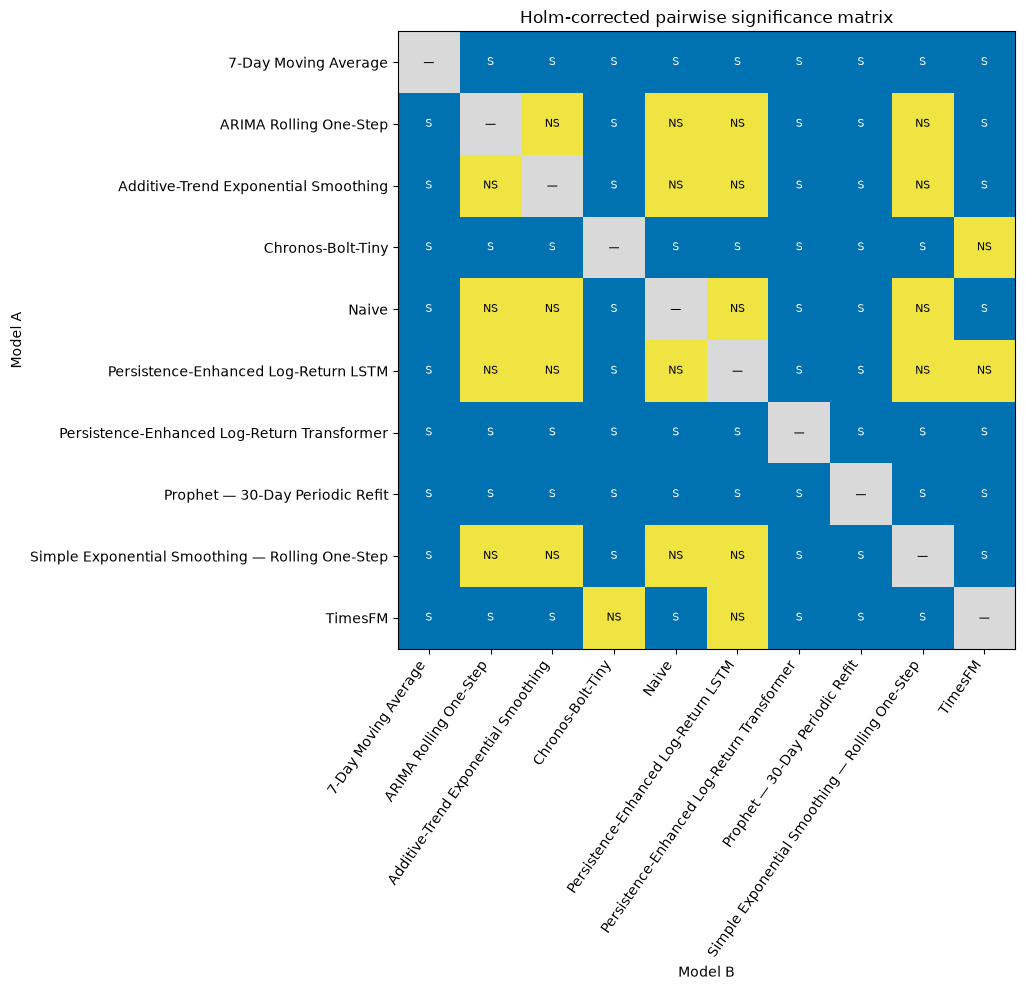

In [3]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Build a symmetric Holm-significance matrix from the 45 frozen pairwise rows.
models = sorted(set(dm['Model A']) | set(dm['Model B']))
holm = pd.DataFrame(np.nan, index=models, columns=models)
for model in models:
    holm.loc[model, model] = -1
for _, row in dm.iterrows():
    value = int(bool(row['Significant Holm?']))
    holm.loc[row['Model A'], row['Model B']] = value
    holm.loc[row['Model B'], row['Model A']] = value

# Render an annotated grid: S = significant, NS = not significant.
fig, ax = plt.subplots(figsize=(11, 10))
ax.imshow(holm.to_numpy(), cmap=ListedColormap(['#D9D9D9', '#F0E442', '#0072B2']), vmin=-1, vmax=1)
ax.set_xticks(range(len(models)), models, rotation=55, ha='right')
ax.set_yticks(range(len(models)), models)
for i in range(len(models)):
    for j in range(len(models)):
        label = '—' if i == j else ('S' if holm.iloc[i, j] == 1 else 'NS')
        ax.text(j, i, label, ha='center', va='center', color='white' if holm.iloc[i, j] == 1 else 'black', fontsize=8)
ax.set(title='Holm-corrected pairwise significance matrix', xlabel='Model B', ylabel='Model A')
fig.tight_layout()
plt.show()

Squared-error loss is used. The Newey–West/Bartlett HAC lag is `floor(4*(N/100)^(2/9))` (6 at N=1,061). Raw and Holm-adjusted p-values are both preserved; Holm significance is the primary family-wise conclusion.

## Key Findings

The 45 HAC Diebold–Mariano comparisons cover every pair among the ten frozen models, using squared-error loss, lag 6, and Holm family-wise adjustment. The symmetric matrix makes the adjusted conclusion explicit for each pair while preserving the full raw and adjusted p-value table as the authoritative numerical evidence.